# 1 — Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# 2 — Load Dataset



In [9]:
data_path = "indeed_uk_datascience_jobs_jan2024.csv"
df = pd.read_csv(data_path)

df.head()

,positionName,salary,company,rating,reviewsCount,jobTypeConsolidated
0,Pricing Analyst,"£70,000 - £85,000 a year",Urban Empire Recruitment,NaN,NaN,"Permanent, Full-time"
1,Lead AI / ML / Data Science Engineer,"£150,000 a year",Founding Teams,NaN,NaN,Part-time
2,Data Scientist,NaN,Depop,4.4,34.0,Permanent
3,Research Fellow in data analysis and machine l...,NaN,UCL,4.1,256.0,"Permanent, Full-time"
4,Senior Data Scientist | Media & Entertainment.,"£70,000 a year",Nicholson Glover Consulting,NaN,NaN,Permanent


# 3 — Quick Check

In [12]:
print(df.shape)
df.info()
df.describe(include="all")


(355, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   positionName         355 non-null    object 
 1   salary               146 non-null    object 
 2   company              355 non-null    object 
 3   rating               241 non-null    float64
 4   reviewsCount         241 non-null    float64
 5   jobTypeConsolidated  277 non-null    object 
dtypes: float64(2), object(4)
memory usage: 16.8+ KB


,positionName,salary,company,rating,reviewsCount,jobTypeConsolidated
count,355,146,355,241.000000,241.000000,277
unique,272,119,255,NaN,NaN,21
top,Data Scientist,"£55,000 - £65,000 a year",Harnham,NaN,NaN,Full-time
freq,29,4,20,NaN,NaN,119
mean,NaN,NaN,NaN,3.847303,2046.273859,NaN
std,NaN,NaN,NaN,0.516320,6376.070657,NaN
min,NaN,NaN,NaN,1.500000,2.000000,NaN
25%,NaN,NaN,NaN,3.500000,18.000000,NaN
50%,NaN,NaN,NaN,3.900000,169.000000,NaN
75%,NaN,NaN,NaN,4.200000,746.000000,NaN


# 4 — Clean Job Title (positionName)

In [15]:
df['position_clean'] = (
    df['positionName']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace('[^a-zA-Z0-9 ]', '', regex=True)
)

df[['positionName', 'position_clean']].head(10)


,positionName,position_clean
0,Pricing Analyst,pricing analyst
1,Lead AI / ML / Data Science Engineer,lead ai ml data science engineer
2,Data Scientist,data scientist
3,Research Fellow in data analysis and machine l...,research fellow in data analysis and machine l...
4,Senior Data Scientist | Media & Entertainment.,senior data scientist media entertainment
5,Data Scientist,data scientist
6,Senior Data Scientist,senior data scientist
7,Junior Data Scientist,junior data scientist
8,Lead Statistician - Health Economic Modelling ...,lead statistician health economic modelling h...
9,"Lead Data Scientist, Medical Imaging",lead data scientist medical imaging


#  5 — Seniority Indicators

In [18]:
df['junior'] = df['position_clean'].str.contains(r"\bjunior\b").astype(int)
df['senior'] = df['position_clean'].str.contains(r"\bsenior\b").astype(int)
df['graduate_keyword'] = df['position_clean'].str.contains(r"\bgraduate\b").astype(int)
df['intern_keyword'] = df['position_clean'].str.contains(r"\bintern\b|\binternship\b").astype(int)
df['mid'] = df['position_clean'].str.contains(r"\bmid\b|\bmidlevel\b|\bmid-level\b").astype(int)

df[['position_clean','junior','senior','graduate_keyword','intern_keyword','mid']].head(10)


,position_clean,junior,senior,graduate_keyword,intern_keyword,mid
0,pricing analyst,0,0,0,0,0
1,lead ai ml data science engineer,0,0,0,0,0
2,data scientist,0,0,0,0,0
3,research fellow in data analysis and machine l...,0,0,0,0,0
4,senior data scientist media entertainment,0,1,0,0,0
5,data scientist,0,0,0,0,0
6,senior data scientist,0,1,0,0,0
7,junior data scientist,1,0,0,0,0
8,lead statistician health economic modelling h...,0,0,0,0,0
9,lead data scientist medical imaging,0,0,0,0,0


# 6 — Skill Indicators

In [21]:
skill_keywords = {
    r"\bpython\b": "python",
    r"\bsql\b": "sql",
    r"\br\b": "r_lang",
    r"\bdata analyst\b": "data_analyst",
    r"\bdata scientist\b": "data_scientist",
    r"\bbusiness analyst\b": "business_analyst",
    r"\bmachine learning\b": "machine_learning",
    r"\bml\b": "machine_learning"   # keep it mapped to same column
}

# create columns safely
for pattern, col in skill_keywords.items():
    if col not in df.columns:
        df[col] = 0
    df[col] = df[col] | df['position_clean'].str.contains(pattern, regex=True).astype(int)

skill_cols = sorted(list(set(skill_keywords.values())))
df[skill_cols].head(10)


,business_analyst,data_analyst,data_scientist,machine_learning,python,r_lang,sql
0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0
5,0,0,1,0,0,0,0
6,0,0,1,0,0,0,0
7,0,0,1,0,0,0,0
8,0,0,0,0,0,0,0
9,0,0,1,0,0,0,0


In [12]:
# 3.2 Skill Indicators

skill_keywords = {
    'python': 'python',
    'sql': 'sql',
    ' r ': 'r_lang',   # space to avoid matching 'director'
    'data analyst': 'data_analyst',
    'data scientist': 'data_scientist',
    'business analyst': 'business_analyst',
    'machine learning': 'machine_learning',
    ' ml ': 'machine_learning'
}

for kw, col in skill_keywords.items():
    df[col] = df['position_clean'].str.contains(kw, case=False, regex=True).astype(int)

skill_cols = list(set(skill_keywords.values()))
df[skill_cols].head()


,python,data_analyst,machine_learning,data_scientist,r_lang,sql,business_analyst
0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0


# 7 — Job Type Encoding (with missing handling)

In [24]:
df['jobTypeConsolidated'] = df['jobTypeConsolidated'].fillna("Unknown")
jobtype_dummies = pd.get_dummies(df['jobTypeConsolidated'], prefix='type')
df = pd.concat([df, jobtype_dummies], axis=1)

jobtype_dummies.head()


,type_Apprenticeship,type_Fixed term contract,type_Freelance,type_Full-time,"type_Full-time, Apprenticeship","type_Full-time, Apprenticeship, Fixed term contract","type_Full-time, Fixed term contract",type_Graduate,type_Internship,type_Part-time,...,"type_Part-time, Full-time, Fixed term contract","type_Part-time, Full-time, Temporary contract","type_Part-time, Temporary contract","type_Part-time, Temporary contract, Fixed term contract",type_Permanent,"type_Permanent, Full-time","type_Permanent, Graduate, Full-time","type_Permanent, Part-time, Full-time",type_Temporary contract,type_Unknown
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


# 8 — Salary Flag (safe)

In [27]:
if 'salary' in df.columns:
    df['has_salary_info'] = df['salary'].notna().astype(int)
else:
    df['has_salary_info'] = 0  # in case salary column missing

df['has_salary_info'].value_counts()


has_salary_info
0    209
1    146
Name: count, dtype: int64

# 9 — Target Label Construction (Graduate vs Non-Graduate)

In [30]:
grad_keywords = ['graduate', 'junior', 'entry', 'trainee', 'intern', 'associate']

def detect_grad_role(title: str) -> int:
    title = str(title)
    return int(any(kw in title for kw in grad_keywords))

df['is_grad_role'] = df['position_clean'].apply(detect_grad_role)

df['is_grad_role'].value_counts(), df[['positionName','position_clean','is_grad_role']].head(20)


(is_grad_role
 0    320
 1     35
 Name: count, dtype: int64,
                                          positionName  \
 0                                     Pricing Analyst   
 1                Lead AI / ML / Data Science Engineer   
 2                                      Data Scientist   
 3   Research Fellow in data analysis and machine l...   
 4      Senior Data Scientist | Media & Entertainment.   
 5                                      Data Scientist   
 6                               Senior Data Scientist   
 7                               Junior Data Scientist   
 8   Lead Statistician - Health Economic Modelling ...   
 9                Lead Data Scientist, Medical Imaging   
 10                                Lead Data Scientist   
 11          Machine Learning Engineer - Life Sciences   
 12  Researcher - Food Engineering – Computer visio...   
 13                     Packaging Waste Data Scientist   
 14               Data Scientist Degree Apprenticeship   
 15  Senio

# 10 — Feature Set + Train/Test Split

In [33]:
extra_cols = ['junior', 'senior', 'graduate_keyword', 'intern_keyword', 'mid', 'has_salary_info']
jobtype_cols = list(jobtype_dummies.columns)

feature_names = skill_cols + extra_cols + jobtype_cols

X = df[feature_names]
y = df['is_grad_role']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()


((284, 35),
 (71, 35),
 is_grad_role
 0    256
 1     28
 Name: count, dtype: int64,
 is_grad_role
 0    64
 1     7
 Name: count, dtype: int64)

# 11 — Logistic Regression Baseline

In [38]:
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.9014084507042254
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        64
           1       0.50      0.57      0.53         7

    accuracy                           0.90        71
   macro avg       0.73      0.75      0.74        71
weighted avg       0.91      0.90      0.90        71



# 12 — Random Forest (Main Model)

In [41]:
rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.9014084507042254
              precision    recall  f1-score   support

           0       0.94      0.95      0.95        64
           1       0.50      0.43      0.46         7

    accuracy                           0.90        71
   macro avg       0.72      0.69      0.70        71
weighted avg       0.90      0.90      0.90        71



# 13 — Confusion Matrix (Save Figure)

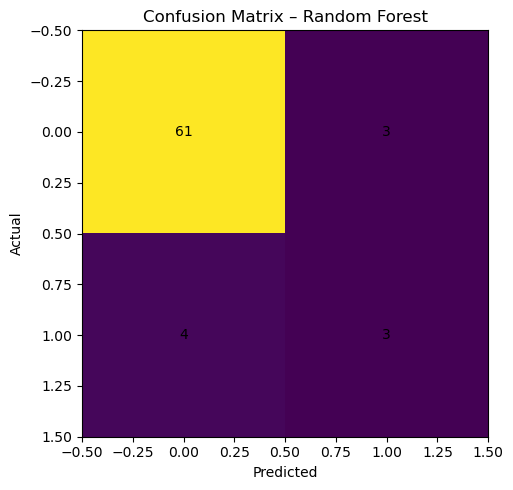

array([[61,  3],
       [ 4,  3]], dtype=int64)

In [44]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# numbers inside
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

cm


# 14 — Feature Importance (Save Figure)

In [47]:
importances = rf.feature_importances_

feat_imp = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
)

feat_imp.head(20)


,feature,importance
7,junior,0.179811
14,type_Fixed term contract,0.127167
2,data_scientist,0.078482
10,intern_keyword,0.072800
34,type_Unknown,0.071893
12,has_salary_info,0.062795
8,senior,0.062718
29,type_Permanent,0.052888
3,machine_learning,0.048798
9,graduate_keyword,0.047646


# 15 — Plot Top 15 (Save Figure)

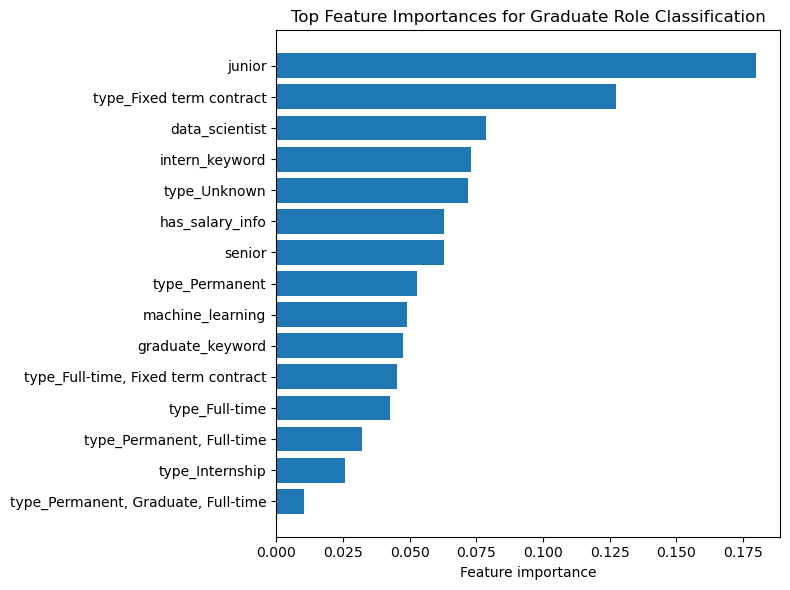

In [55]:
top_n = 15
top_feats = feat_imp.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_feats['feature'], top_feats['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Top Feature Importances for Graduate Role Classification")
plt.tight_layout()

plt.savefig("feature_importance_top15.png", dpi=300, bbox_inches="tight")
plt.show()


# 16 — Save Outputs

In [53]:
df.to_csv("processed_uk_datascience_jobs_with_features.csv", index=False)
feat_imp.to_csv("feature_importance_results.csv", index=False)

print("Saved:")
print("- processed_uk_datascience_jobs_with_features.csv")
print("- feature_importance_results.csv")
print("- confusion_matrix_rf.png")
print("- feature_importance_top15.png")


Saved:
- processed_uk_datascience_jobs_with_features.csv
- feature_importance_results.csv
- confusion_matrix_rf.png
- feature_importance_top15.png
